# TIPTOP residual PSDs and spatial-frequency sampling

**The simulation defines the spatial grid; the spatial grid defines the Fourier grid; TIPTOP is configured to evaluate the residual AO PSD on compatible frequency samples.**

FIATLUX owns `N`, `dx`, the physical extent and pupil padding. This notebook never changes an existing simulation grid to accommodate TIPTOP. No PSD interpolation and no fitted RMS normalization are used.

Optional environment: `python -m pip install -e '.[tiptop,tutorials]'` (Python 3.12 tested). The installed TIPTOP package supplies the HARMONI SCAO preset and its assets; no unexplained local files are required. This notebook uses TIPTOP 1.5.1 / P3 1.6.2. The additional P3-side sampling hook is explicitly opted into below.

Sources: [ORION presets](https://astro-tiptop-services.github.io/astro-tiptop-services/docs/orion/interactivetools/), [P3 frequencyDomain](https://github.com/astro-tiptop/P3/blob/main/p3/aoSystem/frequencyDomain.py), [P3 fourierModel](https://github.com/astro-tiptop/P3/blob/main/p3/aoSystem/fourierModel.py). Equations below describe the pinned installed versions.

In [1]:
from pathlib import Path
import sys
root = Path.cwd() if (Path.cwd() / "fiatlux").exists() else Path.cwd().parent
if str(root) not in sys.path:
    sys.path.insert(0, str(root))
import copy, json, math
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from fiatlux import (Grid, Spectrum, PhotometricBand, Field, FieldDimension,
                     tiptop_psd, load_harmoni_scao_config, TiptopSamplingError)
from fiatlux.optics.tiptop import configure_tiptop_sampling
plt.rcParams.update({"figure.dpi": 110, "axes.grid": False})
torch.set_num_threads(4)

## 1. What is a spatial PSD?

Let $h(x,y)$ be a stationary random **OPD in metres**. With spatial frequencies in cycles/m, its density $W_h$ satisfies
$$\sigma_h^2=\iint W_h(f_x,f_y)\,df_x\,df_y
\simeq\sum_{ij}W_h(f_i,f_j)\Delta f_x\Delta f_y.$$
Thus $W_h$ has units m²/(cycles/m)², conventionally **m⁴**. A plot in nm² m² uses OPD squared in nm² instead.

Phase at wavelength $\lambda$ is $\phi=2\pi h/\lambda$, hence
$$W_h=(\lambda/2\pi)^2W_\phi.$$
FIATLUX stores **unshifted phase density in rad² m²**. Changing the reference wavelength changes phase, not OPD.

**Important P3 convention:** despite a legacy density docstring, `powerSpectrumDensity()` returns centered **OPD power per Fourier bin in nm²**, after multiplying by $(dk\,\lambda_\mathrm{ref}[\mathrm{nm}]/2\pi)^2$. Here $dk=2k_c/\mathrm{resAO}$; integer truncation means it need not exactly equal `PSDstep`. FIATLUX preserves that returned bin power and divides by the target $\Delta f^2$ exactly once. It does not multiply by P3's `dk` a second time.

## 2. Physical grid → Fourier grid

For $N$ pixels at pitch $\Delta x$: $L=N\Delta x$, $\Delta f=1/L$, and $f_\mathrm{Nyquist}=1/(2\Delta x)$. For even $N$, FFT samples include the negative Nyquist endpoint but not the positive endpoint.

The following cell defines a **standalone example simulation input**, using the supplied HARMONI values. In an existing simulation, use its existing `pupil_grid` directly; do not reconstruct it from the telescope diameter. `D/N` is chosen here only to demonstrate the difficult no-padding case.

In [2]:
D = 38.542  # m, physical telescope diameter
N = 400
pupil_grid = Grid(N, N, D/N, D/N, dtype=torch.float64)
original_grid = copy.deepcopy(pupil_grid.__dict__)
spectrum = Spectrum(magnitude=14, band=PhotometricBand.HCM2, samples=3, dtype=torch.float64)
L = pupil_grid.nx * pupil_grid.dx
df = 1/L
f = torch.fft.fftshift(torch.fft.fftfreq(pupil_grid.nx, d=pupil_grid.dx, dtype=torch.float64))
print(f"N={N}; D={D:.6f} m; L={L:.6f} m; dx={pupil_grid.dx:.9f} m")
print(f"df={df:.12f} cycles/m; Nyquist={1/(2*pupil_grid.dx):.6f} cycles/m")
print("Frequency endpoints and DC [cycles/m]:", f[[0, 1, N//2, -2, -1]].tolist())
print("HCM2 wavelengths [µm]:", (spectrum.wavelengths * 1e6).tolist())

N=400; D=38.542000 m; L=38.542000 m; dx=0.096355000 m
df=0.025945721551 cycles/m; Nyquist=5.189144 cycles/m
Frequency endpoints and DC [cycles/m]: [-5.189144310103264, -5.163198588552747, 0.0, 5.137252867002231, 5.163198588552747]
HCM2 wavelengths [µm]: [1.0750000000000002, 1.1, 1.125]


## 3. Why padding matters

Two separately defined simulations can contain the same pupil but different numerical extents. This comparison does **not** replace the input grid above. At fixed pitch, adding padding increases $L$ and decreases $\Delta f$, while keeping the Nyquist frequency unchanged. A diameter alone cannot determine a Fourier grid.

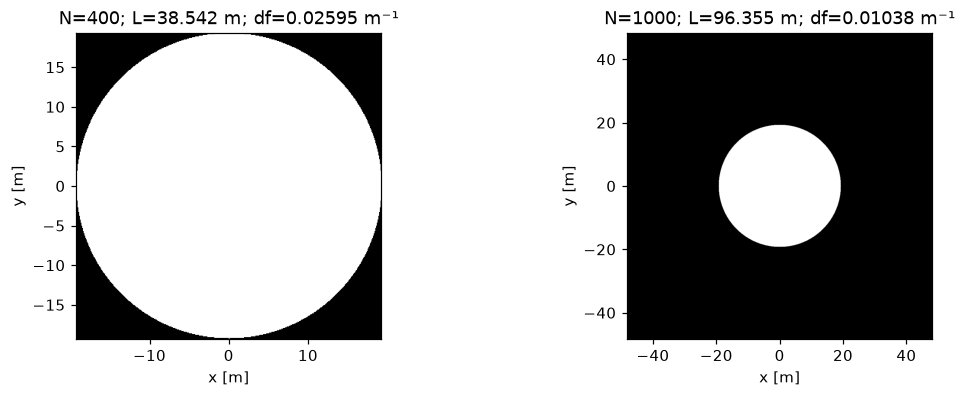

In [3]:
comparison = [pupil_grid, Grid(1000, 1000, pupil_grid.dx, pupil_grid.dy, dtype=torch.float64)]
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), constrained_layout=True)
for ax, grid in zip(axes, comparison):
    x, y = grid.meshgrid()
    pupil = (x*x+y*y <= (D/2)**2).numpy()
    extent = grid.nx*grid.dx
    ax.imshow(pupil, origin="lower", extent=np.array([-1,1,-1,1])*extent/2, cmap="gray")
    ax.set(title=f"N={grid.nx}; L={extent:.3f} m; df={1/extent:.5f} m⁻¹", xlabel="x [m]", ylabel="y [m]")
plt.show()
assert pupil_grid.__dict__ == original_grid

## 4. How P3 constructs its grid

For camera pixel size $p$ in mas and $R=206264806.247$ mas/rad, P3 computes, for each science wavelength,
$$s=\lambda R/(pD),\quad k=\lceil2/s\rceil,\quad \mathrm{samp}=ks,\quad \Delta f_\lambda=p/(\lambda Rk).$$
`PSDstep` is the minimum $\Delta f_\lambda$. With PSD expansion, `kRef_` is the ceiling of $k_i\lambda_i/\lambda_\min$ for the channel that supplies that minimum; `nOtf = FieldOfView * kRef_`. It need not be one. P3's `kx_`, `ky_` are centered coordinates with a numerical $10^{-10}$ cycles/m offset.

There is a real limitation: $k\ge2/s$ implies **`PSDstep ≤ 1/(2D)`**. A grid whose extent is only $D$ cannot be requested through `PixelScale` and `FieldOfView` alone. Enlarging FIATLUX to satisfy this condition would violate the contract.

The public API therefore fails in configuration-only mode. For this case it offers an explicit, version-gated **P3-side frequency-domain adapter**, supplied through P3's `fourierModel(freq=...)` interface. It overrides P3's `PSDstep` and `nOtf` assignments **before** P3 builds its frequencies, masks, AO support and filters. It does not modify FIATLUX or interpolate PSD values. This is a PSD evaluator, not a replacement TIPTOP PSF camera interface.

In [4]:
config = load_harmoni_scao_config()
physical_overrides = {
    "telescope": {"TelescopeDiameter": D, "ZenithAngle": 52.4},
    "sources_science": {"Wavelength": spectrum.wavelengths.tolist()},
}
example_config = copy.deepcopy(config)
for section, values in physical_overrides.items():
    example_config[section].update(values)
try:
    configure_tiptop_sampling(pupil_grid, example_config)
except TiptopSamplingError as error:
    print("Expected configuration-only incompatibility:", error)
# A different, already padded simulation can use the standard configuration path.
padded_config = configure_tiptop_sampling(comparison[1], example_config)
print("Independent padded example sensor configuration:", padded_config["sensor_science"])

Cupy import failed. P3 will fall back to CPU use.


Cupy import failed. MASTSEL will fall back to CPU use.


Cupy import failed. SEEING will fall back to CPU use.


Expected configuration-only incompatibility: FIATLUX df=0.0259457215505 cycles/m exceeds P3's configuration limit 1/(2D)=0.0129728607753. No PixelScale/FieldOfView pair can match. Keep FIATLUX unchanged; explicitly request explicit_sampling=True to use the pinned P3 frequency-domain adapter.
Independent padded example sensor configuration: {'PixelScale': 2.4082601528512626, 'FieldOfView': 500}


## 5. Configure P3 to the unchanged FIATLUX target

The physical starting point is TIPTOP's installed **HARMONI SCAO NGS** preset. Only diameter, zenith and HCM2 wavelengths are overridden here. Atmosphere, DM, WFS and loop settings remain inspectable configuration data.

The science magnitude 14 sets FIATLUX source flux. It is **not** converted into WFS photons: that requires a guide-star band, throughput and flux calibration. This example retains the preset's `NumberPhotons`. To change the AO brightness, override that calibrated photons/subaperture/frame value. Static errors are separate from the residual atmospheric/AO PSD. The loop frequency shapes the residual statistics; it does not turn independent draws into a temporal sequence.

In [5]:
result = tiptop_psd(pupil_grid, config=config, overrides=physical_overrides, explicit_sampling=True)
assert result.grid is pupil_grid
assert pupil_grid.__dict__ == original_grid
assert result.diagnostics["nOtf"] == pupil_grid.nx
assert math.isclose(result.diagnostics["PSDstep"], df, rel_tol=1e-12)
print(json.dumps(result.diagnostics, indent=2))
print("Atmosphere:", result.config["atmosphere"])
print("WFS photons/subap/frame:", result.config["sensor_HO"]["NumberPhotons"])
print("AO loop [Hz]:", result.config["RTC"]["SensorFrameRate_HO"])
print("P3 camera metadata:", result.config["sensor_science"])
print("In explicit mode k_/kRef_/camera values describe upstream camera initialization; nOtf and PSDstep are the verified evaluator grid.")

{
  "p3_version": "1.6.2",
  "tiptop_version": "1.5.1",
  "mode": "explicit P3 frequency domain",
  "nOtf": 400,
  "target_N": 400,
  "PSDstep": 0.025945721550516318,
  "target_df": 0.025945721550516318,
  "k_": [
    3,
    2,
    2
  ],
  "kRef_": 3,
  "samp": [
    2.9999999999999996,
    2.0465116279069764,
    2.093023255813953
  ],
  "crop_start": 0,
  "crop_stop": 400,
  "rms_nm": [
    144.15102385913576
  ],
  "full_p3_rms_nm": [
    144.15102385913573
  ],
  "p3_normalization_dk": 0.026055237102657634,
  "ao_cutoff_cycles_per_m": 1.3157894736842106,
  "component_sum_matches_total": true
}
Atmosphere: {'Wavelength': 5e-07, 'Seeing': 0.65, 'L0': 25.0, 'Cn2Weights': [0.43840001, 0.14700001, 0.1142, 0.056, 0.03683, 0.0442, 0.0527, 0.0794, 0.01829, 0.012939], 'Cn2Heights': [83.16413254, 243.29187551, 710.47154255, 2735.63637091, 5583.67373605, 8599.18858474, 11598.92106005, 14221.06437269, 17219.02406272, 21912.89106645], 'WindSpeed': [6.6, 5.9, 5.1, 4.5, 5.1, 8.3, 16.3, 10.2, 14.

The API checks **actual** `PSDstep`, `nOtf`, `kx_` and `ky_` before and after the calculation, against `fftshift(fftfreq(...))`. Equal array shapes alone are insufficient.

For a larger P3 array with identical spacing, an integer centered slice aligned on DC retains the exact original samples. Cropping discards power outside the FIATLUX frequency range; it does not renormalize the retained values. Here no crop is needed.

## 6. The residual PSD

The dashed circle marks the P3 DM cutoff, not a sharp boundary between zero and nonzero residuals. Within it, imperfect correction leaves noise, aliasing and spatio-temporal errors; beyond it, fitting error remains. The plots show OPD density, not phase density or bin power.

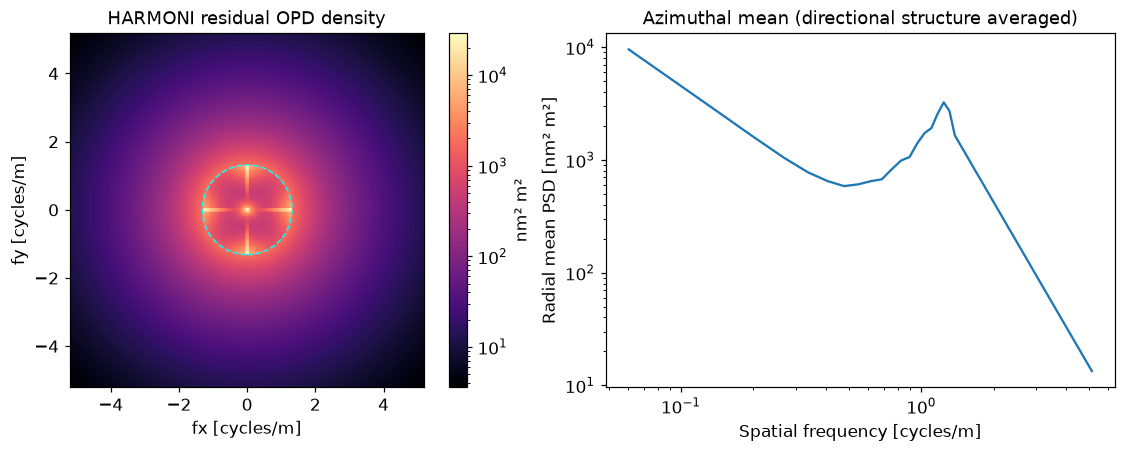

In [6]:
plt.rcdefaults()
plt.rcParams.update({"font.size": 11, "axes.titlesize": 12, "figure.dpi": 110})
density = torch.fft.fftshift(result.opd_psd[0]).cpu().numpy() * 1e18 # nm² m²
fx, fy = np.meshgrid(f.numpy(), f.numpy())
radius = np.hypot(fx, fy)
edges = np.linspace(df, f.max().item(), 75)
counts = np.histogram(radius, edges)[0]
def radial(values):
    return np.histogram(radius, edges, weights=values)[0] / np.maximum(counts, 1)
fmid = (edges[1:] + edges[:-1])/2
fig, axes = plt.subplots(1,2,figsize=(11,4),constrained_layout=True)
im = axes[0].pcolormesh(f.numpy(), f.numpy(), density, norm=LogNorm(), cmap="magma", shading="auto")
axes[0].add_patch(plt.Circle((0,0), result.diagnostics["ao_cutoff_cycles_per_m"], fill=False, color="cyan", linestyle="--"))
axes[0].set(xlabel="fx [cycles/m]", ylabel="fy [cycles/m]", title="HARMONI residual OPD density", aspect="equal")
fig.colorbar(im, ax=axes[0], label="nm² m²")
axes[1].loglog(fmid, radial(density))
axes[1].set(xlabel="Spatial frequency [cycles/m]", ylabel="Radial mean PSD [nm² m²]", title="Azimuthal mean (directional structure averaged)")
plt.show()

## 7. Components actually exposed by P3

P3 exposes fitting, noise, aliasing, **combined spatio-temporal** error, chromatism and differential refraction for this configuration. The combined term is not relabelled as pure servo lag or split into unexposed independent terms. The adapter applies the same bin-power multiplier as the total and embeds the AO-sized components at the same indices as P3. The sum is checked below; quadrature addition applies to these modeled PSD terms, not to arbitrary correlated error sources.

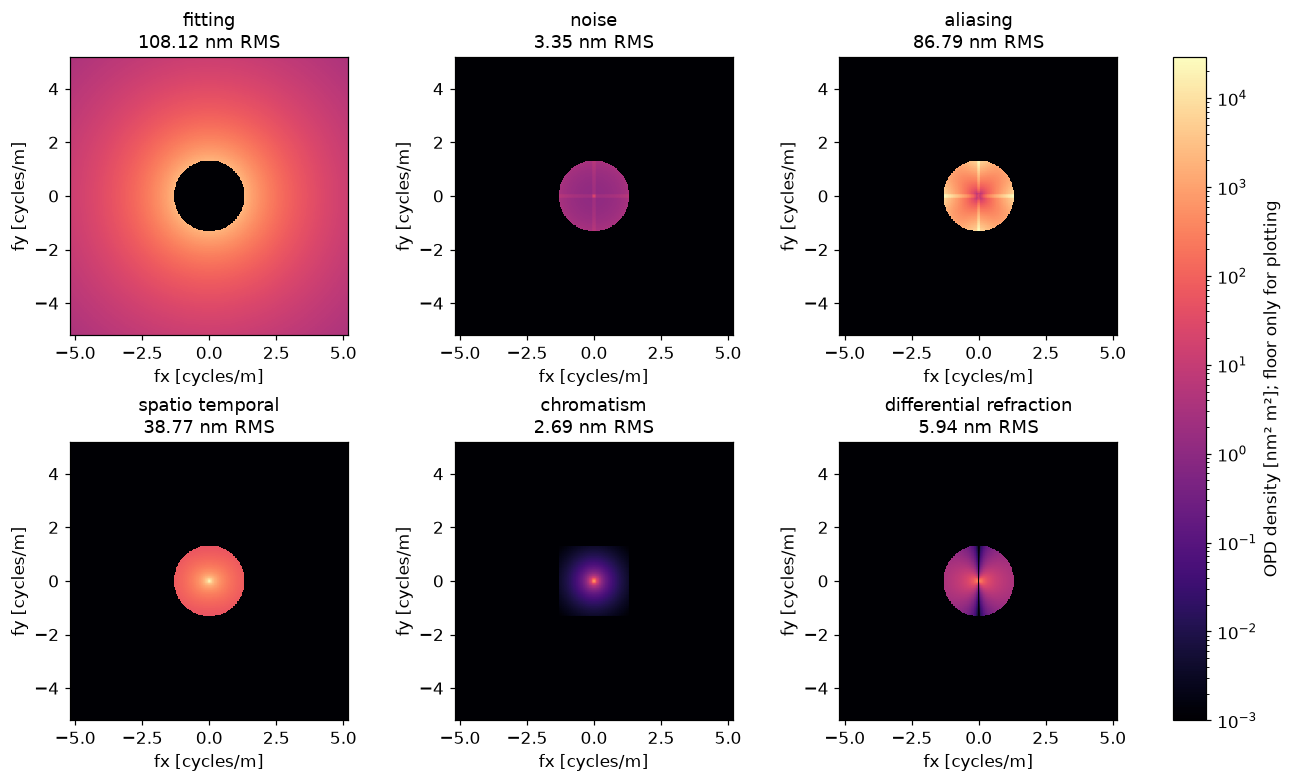

Component sum equals returned total: True


In [7]:
assert result.diagnostics["component_sum_matches_total"]
fig, axes = plt.subplots(2,3,figsize=(12,7),constrained_layout=True)
for ax, (name, power) in zip(axes.flat, result.components_nm2.items()):
    data = power[0].cpu().numpy()/df**2
    rms = float(power[0].sum().sqrt())
    im = ax.pcolormesh(f.numpy(), f.numpy(), np.maximum(data, 1e-6), norm=LogNorm(1e-3, max(1, density.max())), cmap="magma", shading="auto")
    ax.set(title=f"{name.replace(chr(95), chr(32))}\n{rms:.2f} nm RMS", xlabel="fx [cycles/m]", ylabel="fy [cycles/m]", aspect="equal")
fig.colorbar(im, ax=axes.ravel().tolist(), label="OPD density [nm² m²]; floor only for plotting")
plt.show()
print("Component sum equals returned total:", result.diagnostics["component_sum_matches_total"])

## 8. Integrated RMS and real-screen symmetry

Compute $\sigma_h=\sqrt{\sum W_h\Delta f^2}$ directly. No desired RMS is supplied anywhere.

A real stationary field requires $W(-f)=W(f)$. Finite P3 grids can be slightly asymmetric (including boundary effects). Screen generation rejects this unless symmetry averaging is **explicitly** requested. Averaging opposite bins changes the asymmetric part, preserves their sum, and is not interpolation or amplitude fitting. Raw P3 power remains available unchanged in `result.power_nm2`. DC is removed when drawing screens; here P3's DC is already zero. Pupil-weighted variance after piston removal is a different statistic from the full-grid ensemble variance validated here.

In [8]:
variance = result.opd_psd[0].sum() * df**2
rms_m = float(variance.sqrt())
model = result.atmosphere_model(symmetrize=True, seed=2026)
assert model.grid is pupil_grid
phase_to_opd = (model.reference_wavelength/(2*np.pi))**2
imported_variance = model.psd.sum() * df**2 * phase_to_opd
torch.testing.assert_close(imported_variance, variance, rtol=1e-12, atol=1e-27)
print(f"Integrated RMS = {rms_m:.9e} m = {rms_m*1e9:.3f} nm OPD")
print(f"Raw inversion asymmetry, L1 / total = {model.inversion_asymmetry:.4%}")
print("P3 normalization dk [cycles/m]:", result.diagnostics["p3_normalization_dk"])
print("Target df [cycles/m]:", df)

Integrated RMS = 1.441510239e-07 m = 144.151 nm OPD
Raw inversion asymmetry, L1 / total = 0.7398%
P3 normalization dk [cycles/m]: 0.026055237102657634
Target df [cycles/m]: 0.025945721550516318


## 9. Monte-Carlo screens and named Field dimensions

Filter real Gaussian noise using FIATLUX's existing PSD generator. Each realization has the same ensemble PSD but a different OPD map. We average **squared OPD / intensities**, not amplitudes. No physical cadence or frozen-flow claim is attached to the `realization` axis.

PSD RMS = 144.151 nm; Monte-Carlo RMS = 144.203 nm
Variance relative error = 0.073% (128 independent screens)


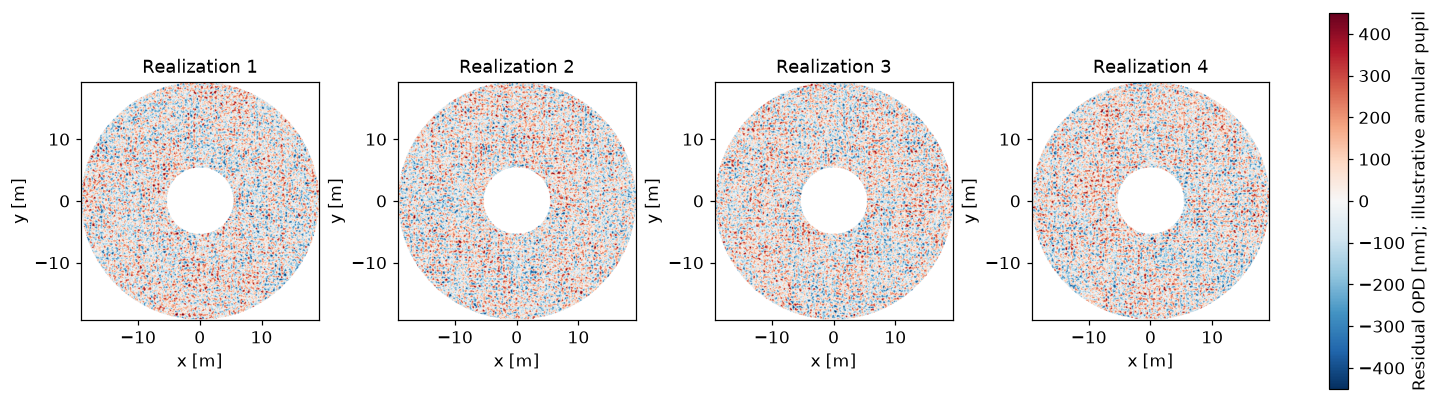

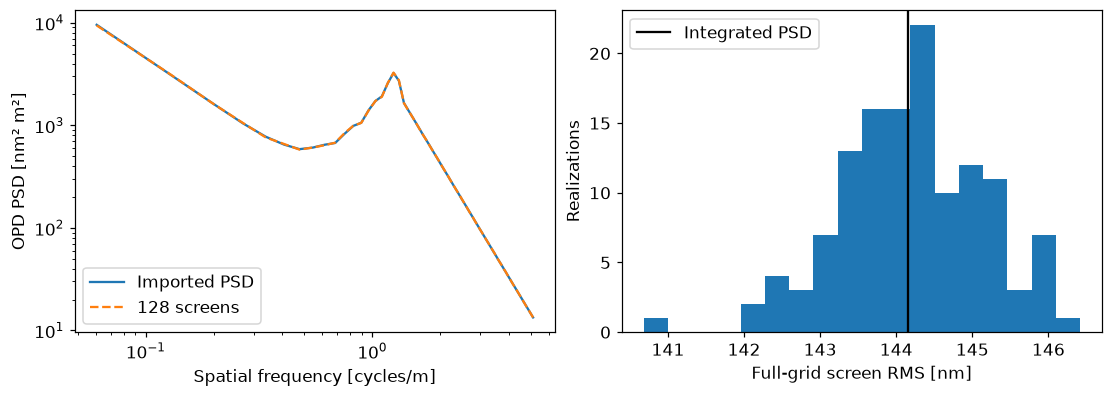

Field shape (realization, wavelength, y, x): (4, 3, 400, 400)


In [9]:
n_realizations = 128
variance_mc = 0.0
measured_power = torch.zeros(pupil_grid.shape, dtype=torch.float64)
rms_samples = []
for start in range(0, n_realizations, 8):
    screens = model.sample_opd_many(8)
    variance_mc += float(screens.square().sum()) / (n_realizations*N*N)
    measured_power += torch.fft.fft2(screens).abs().square().sum(0) / (n_realizations*(N*N)**2)
    rms_samples.extend((screens.square().mean((-2,-1)).sqrt()*1e9).tolist())
    if start == 0:
        examples = screens[:4].clone()
error = variance_mc / float(variance) - 1
assert abs(error) < .03
print(f"PSD RMS = {rms_m*1e9:.3f} nm; Monte-Carlo RMS = {np.sqrt(variance_mc)*1e9:.3f} nm")
print(f"Variance relative error = {error:.3%} ({n_realizations} independent screens)")
x,y = pupil_grid.meshgrid()
pupil = ((x*x+y*y < (D/2)**2) & (x*x+y*y > (.28*D/2)**2))
fig, axes = plt.subplots(1,4,figsize=(13,3.5),constrained_layout=True)
for i,ax in enumerate(axes):
    data = np.ma.masked_where(~pupil.numpy(), examples[i].numpy()*1e9)
    im=ax.imshow(data,origin="lower",extent=[-L/2,L/2,-L/2,L/2],cmap="RdBu_r",vmin=-450,vmax=450)
    ax.set(title=f"Realization {i+1}",xlabel="x [m]",ylabel="y [m]")
fig.colorbar(im,ax=axes,label="Residual OPD [nm]; illustrative annular pupil")
plt.show()
fig,axes=plt.subplots(1,2,figsize=(10,3.5),constrained_layout=True)
measured_density=torch.fft.fftshift(measured_power).numpy()/df**2*1e18
symmetric_density=torch.fft.fftshift(model.psd).numpy()*phase_to_opd*1e18
axes[0].loglog(fmid,radial(symmetric_density),label="Imported PSD")
axes[0].loglog(fmid,radial(measured_density),"--",label="128 screens")
axes[0].set(xlabel="Spatial frequency [cycles/m]",ylabel="OPD PSD [nm² m²]");axes[0].legend()
axes[1].hist(rms_samples,bins=18)
axes[1].axvline(rms_m*1e9,color="black",label="Integrated PSD")
axes[1].set(xlabel="Full-grid screen RMS [nm]",ylabel="Realizations");axes[1].legend()
plt.show()
# Apply the same physical OPD to every science wavelength.
amplitude = pupil.to(torch.complex128).expand(3,N,N).clone()
field = Field(amplitude, pupil_grid, spectrum)
cube = field.apply_opd(examples, dimensions=(FieldDimension("realization",4),))
assert cube.complex_amplitude.shape == (4,3,N,N)
assert cube.grid is pupil_grid
assert pupil_grid.__dict__ == original_grid
print("Field shape (realization, wavelength, y, x):",tuple(cube.complex_amplitude.shape))

## 10. Common sampling mistakes

| Mistake | What to check |
|---|---|
| Same shape, different frequency step | Verify `PSDstep` and actual coordinates, not only `nOtf`. |
| Same diameter, different padding | Derive extent from `Grid.nx * Grid.dx`, never from diameter alone. |
| Resize FIATLUX to suit TIPTOP | Keep the simulation unchanged; configure or explicitly adapt the P3 evaluator. |
| Interpolate a PSD | Reject incompatible increments; only exact centered subsets are allowed. |
| Forget `fftshift` | P3 outputs centered bin powers; FIATLUX stores native FFT order. |
| Confuse OPD and phase | Use the wavelength-squared conversion with explicit units. |
| Omit the bin area | Density integration requires `df**2`; bin power already includes integration. |
| Force a requested RMS | Preserve physical P3 power; compare Monte-Carlo statistics instead. |
| Set only `FieldOfView` | Also inspect wavelength-dependent `k_`, `kRef_`, `PSDstep`, `kx_`, `ky_`. |
| Interpret screens as a time series | A spatial residual PSD does not determine temporal correlations. |

**Limits:** square isotropic grids and single-NGS SCAO; explicit sampling pinned to P3 1.6.2; static OPD is separate; default WFS flux is the preset value until a guide-star calibration is supplied. The exact-grid hook belongs on the P3 side. An upstream constructor extension accepting `PSDstep` and `nOtf` before grid construction could replace the small local subclass. The tutorial does not claim validation of a complete HARMONI instrument model.